<a href="https://colab.research.google.com/github/SabrinaZ600/AI-four-dimension-project/blob/main/AIVisibility_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# ==========================================================
# Import Libraries
# ==========================================================

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import statsmodels.api as sm

In [18]:
# ==========================================================
# Project Directory
# ==========================================================

PROJECT_DIR = "/content/drive/MyDrive/AI_Brand_Project"

DATA_DIR = os.path.join(PROJECT_DIR, "data")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "output")

# ==========================================================
# Figure Directory
# ==========================================================

FIGURE_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(FIGURE_DIR, exist_ok=True)

In [19]:
import shutil

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

In [20]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [21]:
ranking_df = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "brand_rankings.csv"
    )
)

ranking_df.head()

,Prompt_ID,Brand,Mention,Rank
0,1,Sony,1,1.0
1,1,Bose,1,2.0
2,1,Sennheiser,1,3.0
3,1,SoundCore,0,NaN
4,1,JBL,0,NaN


In [22]:
# ==========================================================
# Create Brand Metrics Dataset
# ==========================================================

brand_metrics = pd.DataFrame({

    "Brand":[
        "Sony",
        "Bose",
        "Sennheiser",
        "SoundCore",
        "JBL",
        "Nothing",
        "Edifier"
    ],

    "Total_Posts":[
        39105,
        33814,
        10389,
        6416,
        12203,
        4408,
        28977
    ],

    "Positive_Proportion":[
        0.17,
        0.24,
        0.07,
        0.30,
        0.22,
        0.09,
        0.12
    ],

    "Trust_Score":[
        4.434,
        4.674,
        4.240,
        4.405,
        4.394,
        4.150,
        4.230
    ],

    "Product_Strength":[
        4.14,
        4.17,
        4.25,
        4.17,
        4.22,
        3.62,
        4.23
    ],

    "Marketing_Strength":[
        0.64553685,
        0.92886686,
        0.06033231,
        0.48841749,
        0.62340474,
        0.36723699,
        0.46449625
    ]

})

brand_metrics

,Brand,Total_Posts,Positive_Proportion,Trust_Score,Product_Strength,Marketing_Strength
0,Sony,39105,0.17,4.434,4.14,0.645537
1,Bose,33814,0.24,4.674,4.17,0.928867
2,Sennheiser,10389,0.07,4.240,4.25,0.060332
3,SoundCore,6416,0.30,4.405,4.17,0.488417
4,JBL,12203,0.22,4.394,4.22,0.623405
5,Nothing,4408,0.09,4.150,3.62,0.367237
6,Edifier,28977,0.12,4.230,4.23,0.464496


In [23]:
# ==========================================================
# Save Brand Metrics
# ==========================================================

brand_metrics_file = os.path.join(
    DATA_DIR,
    "brand_metrics.csv"
)

brand_metrics.to_csv(
    brand_metrics_file,
    index=False
)

print("Saved to:")
print(brand_metrics_file)

Saved to:
/content/drive/MyDrive/AI_Brand_Project/data/brand_metrics.csv


In [24]:
# ==========================================================
# Load Brand Metrics
# ==========================================================

brand_df = pd.read_csv(
    brand_metrics_file
)

brand_df

,Brand,Total_Posts,Positive_Proportion,Trust_Score,Product_Strength,Marketing_Strength
0,Sony,39105,0.17,4.434,4.14,0.645537
1,Bose,33814,0.24,4.674,4.17,0.928867
2,Sennheiser,10389,0.07,4.240,4.25,0.060332
3,SoundCore,6416,0.30,4.405,4.17,0.488417
4,JBL,12203,0.22,4.394,4.22,0.623405
5,Nothing,4408,0.09,4.150,3.62,0.367237
6,Edifier,28977,0.12,4.230,4.23,0.464496


In [25]:
# ==========================================================
# Merge AI Visibility with Brand Metrics
# ==========================================================

analysis_df = ranking_df.merge(
    brand_df,
    on="Brand",
    how="left"
)

analysis_df.head(10)

,Prompt_ID,Brand,Mention,Rank,Total_Posts,Positive_Proportion,Trust_Score,Product_Strength,Marketing_Strength
0,1,Sony,1,1.0,39105,0.17,4.434,4.14,0.645537
1,1,Bose,1,2.0,33814,0.24,4.674,4.17,0.928867
2,1,Sennheiser,1,3.0,10389,0.07,4.240,4.25,0.060332
3,1,SoundCore,0,NaN,6416,0.30,4.405,4.17,0.488417
4,1,JBL,0,NaN,12203,0.22,4.394,4.22,0.623405
5,1,Nothing,0,NaN,4408,0.09,4.150,3.62,0.367237
6,1,Edifier,0,NaN,28977,0.12,4.230,4.23,0.464496
7,2,Sony,1,1.0,39105,0.17,4.434,4.14,0.645537
8,2,Bose,1,NaN,33814,0.24,4.674,4.17,0.928867
9,2,Sennheiser,1,NaN,10389,0.07,4.240,4.25,0.060332


In [26]:
print("Rows:", len(analysis_df))

print("\nMissing values:")

analysis_df.isna().sum()

Rows: 98

Missing values:


,0
Prompt_ID,0
Brand,0
Mention,0
Rank,41
Total_Posts,0
Positive_Proportion,0
Trust_Score,0
Product_Strength,0
Marketing_Strength,0


In [27]:
analysis_file = os.path.join(
    OUTPUT_DIR,
    "analysis_dataset.csv"
)

analysis_df.to_csv(
    analysis_file,
    index=False
)

print("Saved!")

Saved!


In [28]:
#Section 3 — Exploratory Data Analysis (EDA)
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Prompt_ID            98 non-null     int64  
 1   Brand                98 non-null     object 
 2   Mention              98 non-null     int64  
 3   Rank                 57 non-null     float64
 4   Total_Posts          98 non-null     int64  
 5   Positive_Proportion  98 non-null     float64
 6   Trust_Score          98 non-null     float64
 7   Product_Strength     98 non-null     float64
 8   Marketing_Strength   98 non-null     float64
dtypes: float64(5), int64(3), object(1)
memory usage: 7.0+ KB


In [32]:
mention_summary = (
    analysis_df
    .groupby("Brand")["Mention"]
    .sum()
    .sort_values(ascending=False)
)

mention_summary

,Mention
Brand,
Bose,14
Sony,14
Sennheiser,13
SoundCore,11
Edifier,6
JBL,6
Nothing,6


In [33]:
rank_summary = (
    analysis_df
    .groupby("Brand")["Rank"]
    .mean()
    .sort_values()
)

rank_summary

,Rank
Brand,
Sony,1.538462
Bose,2.000000
Sennheiser,2.700000
SoundCore,4.000000
JBL,4.200000
Edifier,5.200000
Nothing,6.400000


In [34]:
#Section 4 — Correlation Analysis
brand_analysis = (
    analysis_df
    .groupby("Brand")
    .agg(
        Mention_Rate=("Mention","mean"),
        Average_Rank=("Rank","mean"),
        Total_Posts=("Total_Posts","first"),
        Positive_Proportion=("Positive_Proportion","first"),
        Trust_Score=("Trust_Score","first"),
        Product_Strength=("Product_Strength","first"),
        Marketing_Strength=("Marketing_Strength","first")
    )
)

brand_analysis

,Mention_Rate,Average_Rank,Total_Posts,Positive_Proportion,Trust_Score,Product_Strength,Marketing_Strength
Brand,,,,,,,
Bose,1.000000,2.000000,33814,0.24,4.674,4.17,0.928867
Edifier,0.428571,5.200000,28977,0.12,4.230,4.23,0.464496
JBL,0.428571,4.200000,12203,0.22,4.394,4.22,0.623405
Nothing,0.428571,6.400000,4408,0.09,4.150,3.62,0.367237
Sennheiser,0.928571,2.700000,10389,0.07,4.240,4.25,0.060332
Sony,1.000000,1.538462,39105,0.17,4.434,4.14,0.645537
SoundCore,0.785714,4.000000,6416,0.30,4.405,4.17,0.488417


In [35]:
corr = brand_analysis.corr(
    numeric_only=True
)

corr.round(3)

,Mention_Rate,Average_Rank,Total_Posts,Positive_Proportion,Trust_Score,Product_Strength,Marketing_Strength
Mention_Rate,1.000,-0.907,0.444,0.218,0.607,0.365,0.184
Average_Rank,-0.907,1.000,-0.613,-0.276,-0.711,-0.591,-0.340
Total_Posts,0.444,-0.613,1.000,0.081,0.547,0.377,0.608
Positive_Proportion,0.218,-0.276,0.081,1.000,0.730,0.325,0.665
Trust_Score,0.607,-0.711,0.547,0.730,1.000,0.423,0.834
Product_Strength,0.365,-0.591,0.377,0.325,0.423,1.000,0.118
Marketing_Strength,0.184,-0.340,0.608,0.665,0.834,0.118,1.000


In [36]:
corr.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "correlation_matrix.csv"
    )
)

In [37]:
# Section 5 Logistic Regression
# ==========================================================
# Logistic Regression
# ==========================================================

model_df = analysis_df.copy()

features = [
    "Total_Posts",
    "Positive_Proportion",
    "Trust_Score",
    "Product_Strength",
    "Marketing_Strength"
]

X = model_df[features]

y = model_df["Mention"]

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [39]:
import statsmodels.api as sm

X_sm = sm.add_constant(X_scaled)

logit_model = sm.Logit(y, X_sm)

result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.403660
         Iterations 30
                           Logit Regression Results                           
Dep. Variable:                Mention   No. Observations:                   98
Model:                          Logit   Df Residuals:                       92
Method:                           MLE   Df Model:                            5
Date:                Wed, 05 Aug 2026   Pseudo R-squ.:                  0.3253
Time:                        05:14:30   Log-Likelihood:                -39.559
converged:                       True   LL-Null:                       -58.630
Covariance Type:            nonrobust   LLR p-value:                 3.531e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.8428        nan        nan        nan         nan         nan
x1            13.9321       

In [40]:
# Section 6 AI Blind Spot
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

brand_strength = brand_df.copy()

cols = [
    "Total_Posts",
    "Positive_Proportion",
    "Trust_Score"
]

brand_strength[cols] = scaler.fit_transform(
    brand_strength[cols]
)

brand_strength["Brand_Strength"] = (
    brand_strength[cols].mean(axis=1)
)

In [41]:
brand_strength["Reality_Rank"] = (
    brand_strength["Brand_Strength"]
    .rank(ascending=False)
)

visibility = pd.read_csv(
    os.path.join(
        OUTPUT_DIR,
        "AI_Visibility_Score.csv"
    )
)

visibility["AI_Rank"] = (
    visibility["AI_Visibility"]
    .rank(ascending=False)
)

In [42]:
comparison = (
    brand_strength[
        ["Brand", "Reality_Rank"]
    ]
    .merge(
        visibility[
            ["Brand", "AI_Rank", "AI_Visibility"]
        ],
        on="Brand"
    )
)

comparison["Gap"] = (
    comparison["Reality_Rank"]
    - comparison["AI_Rank"]
)

comparison

,Brand,Reality_Rank,AI_Rank,AI_Visibility,Gap
0,Sony,2.0,1.0,100.000000,1.0
1,Bose,1.0,2.0,70.701767,-1.0
2,Sennheiser,6.0,3.0,57.167087,3.0
3,SoundCore,3.0,4.0,31.360846,-1.0
4,JBL,4.0,5.0,6.067140,-1.0
5,Nothing,7.0,7.0,0.000000,0.0
6,Edifier,5.0,6.0,3.748783,-1.0


In [43]:
def classify_gap(gap):

    if gap >= 2:

        return "AI Over-recommended"

    elif gap <= -2:

        return "AI Under-recommended"

    else:

        return "Aligned"

comparison["Classification"]=comparison["Gap"].apply(classify_gap)

comparison

,Brand,Reality_Rank,AI_Rank,AI_Visibility,Gap,Classification
0,Sony,2.0,1.0,100.000000,1.0,Aligned
1,Bose,1.0,2.0,70.701767,-1.0,Aligned
2,Sennheiser,6.0,3.0,57.167087,3.0,AI Over-recommended
3,SoundCore,3.0,4.0,31.360846,-1.0,Aligned
4,JBL,4.0,5.0,6.067140,-1.0,Aligned
5,Nothing,7.0,7.0,0.000000,0.0,Aligned
6,Edifier,5.0,6.0,3.748783,-1.0,Aligned


In [44]:
# Section 7 Prompt-Level AI Recommendation Heatmap
# ==========================================================
# Prompt × Brand Mention Matrix
# ==========================================================

mention_matrix = (
    analysis_df
    .pivot_table(
        index="Prompt_ID",
        columns="Brand",
        values="Mention",
        fill_value=0
    )
)

mention_matrix

Brand,Bose,Edifier,JBL,Nothing,Sennheiser,Sony,SoundCore
Prompt_ID,,,,,,,
1,1.0,0.0,0.0,0.0,1.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,1.0,1.0
3,1.0,0.0,0.0,0.0,1.0,1.0,1.0
4,1.0,0.0,0.0,0.0,1.0,1.0,1.0
5,1.0,0.0,0.0,0.0,1.0,1.0,0.0
6,1.0,0.0,0.0,0.0,1.0,1.0,0.0
7,1.0,0.0,0.0,0.0,1.0,1.0,1.0
8,1.0,0.0,0.0,0.0,0.0,1.0,1.0
9,1.0,1.0,1.0,1.0,1.0,1.0,1.0


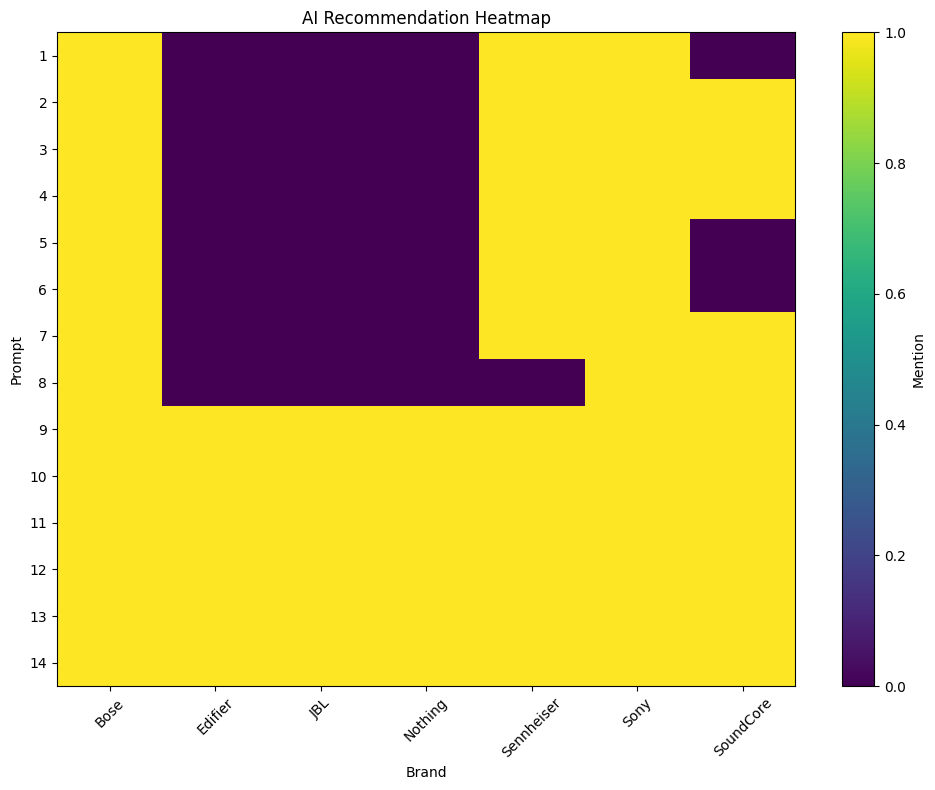

In [45]:
# ==========================================================
# Mention Heatmap
# ==========================================================

plt.figure(figsize=(10,8))

plt.imshow(
    mention_matrix,
    aspect="auto"
)

plt.colorbar(label="Mention")

plt.xticks(
    range(len(mention_matrix.columns)),
    mention_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(mention_matrix.index)),
    mention_matrix.index
)

plt.xlabel("Brand")

plt.ylabel("Prompt")

plt.title("AI Recommendation Heatmap")

plt.tight_layout()

plt.show()

In [46]:
rank_matrix = (
    analysis_df
    .pivot_table(
        index="Prompt_ID",
        columns="Brand",
        values="Rank"
    )
)

rank_matrix

Brand,Bose,Edifier,JBL,Nothing,Sennheiser,Sony,SoundCore
Prompt_ID,,,,,,,
1,2.0,NaN,NaN,NaN,3.0,1.0,NaN
2,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,2.0,NaN,NaN,NaN,3.0,1.0,5.0
4,2.0,NaN,NaN,NaN,3.0,1.0,4.0
5,1.0,NaN,NaN,NaN,3.0,2.0,NaN
6,2.0,NaN,NaN,NaN,3.0,1.0,NaN
7,NaN,NaN,NaN,NaN,NaN,1.0,NaN
8,2.0,NaN,NaN,NaN,NaN,3.0,1.0
9,2.0,6.0,4.0,7.0,3.0,1.0,5.0


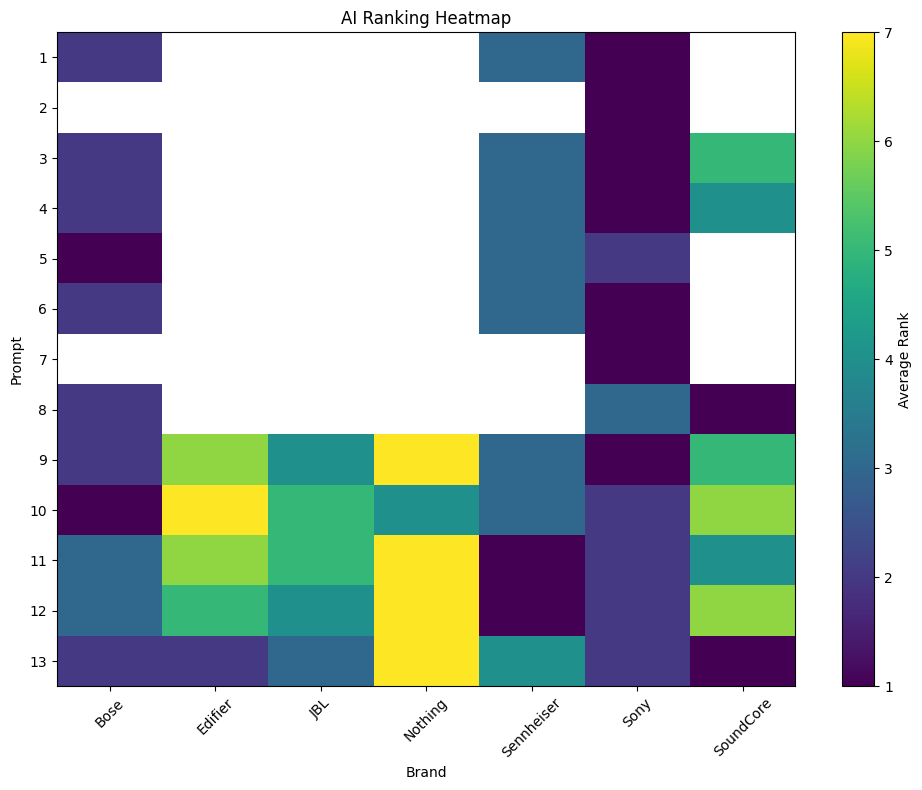

In [47]:
plt.figure(figsize=(10,8))

plt.imshow(
    rank_matrix,
    aspect="auto"
)

plt.colorbar(label="Average Rank")

plt.xticks(
    range(len(rank_matrix.columns)),
    rank_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(rank_matrix.index)),
    rank_matrix.index
)

plt.xlabel("Brand")

plt.ylabel("Prompt")

plt.title("AI Ranking Heatmap")

plt.tight_layout()

plt.show()

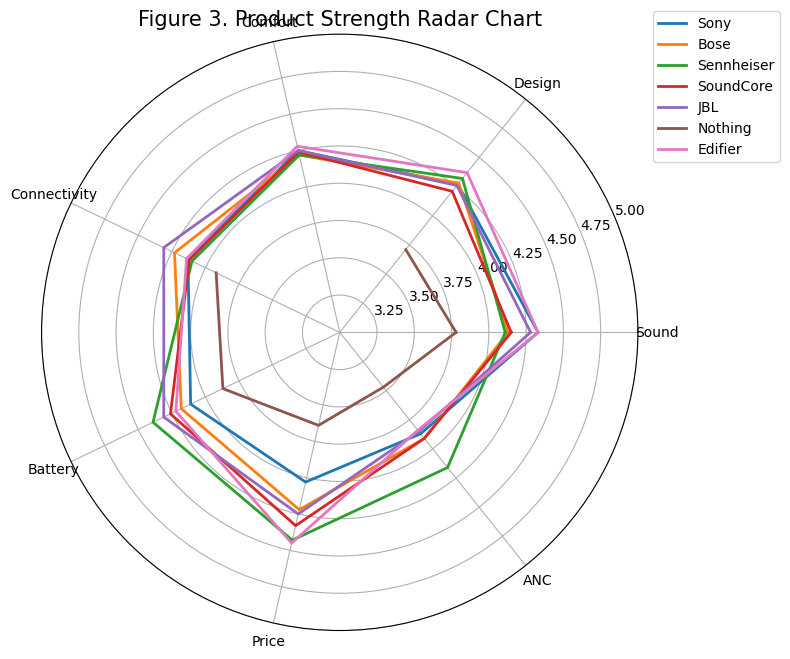

In [ ]:
# ==========================================================
# Additional Plots
# Figure 3 Product Strength Radar Chart
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

categories = [
    "Sound",
    "Design",
    "Comfort",
    "Connectivity",
    "Battery",
    "Price",
    "ANC"
]

product_scores = {

    "Sony":[4.33,4.27,4.25,4.13,4.11,4.03,3.87],
    "Bose":[4.13,4.28,4.22,4.23,4.18,4.22,3.91],
    "Sennheiser":[4.11,4.32,4.22,4.10,4.39,4.43,4.16],
    "SoundCore":[4.15,4.21,4.24,4.12,4.26,4.33,3.91],
    "JBL":[4.28,4.26,4.25,4.31,4.31,4.25,3.85],
    "Nothing":[3.78,3.71,2.98,3.92,3.87,3.64,3.47],
    "Edifier":[4.33,4.37,4.28,4.14,4.22,4.45,3.84]

}

angles = np.linspace(
    0,
    2*np.pi,
    len(categories),
    endpoint=False
).tolist()

angles += angles[:1]

fig = plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for brand, values in product_scores.items():

    values = values + values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=brand
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(3,5)

plt.legend(
    bbox_to_anchor=(1.25,1.05)
)

plt.title(
    "Figure 3. Product Strength Radar Chart",
    fontsize= 15
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "Figure3_ProductStrengthRadar.png"
    ),
    dpi=300
)

plt.show()

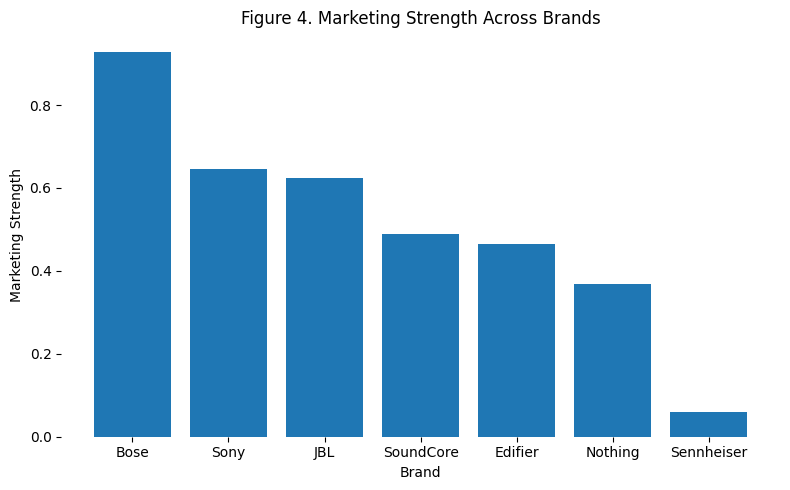

In [48]:
# ==========================================================
# Figure 4 Marketing Strength
# ==========================================================

import matplotlib.pyplot as plt

marketing = brand_df.sort_values(
    "Marketing_Strength",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    marketing["Brand"],
    marketing["Marketing_Strength"]
)

plt.ylabel("Marketing Strength")

plt.xlabel("Brand")

plt.title(
    "Figure 4. Marketing Strength Across Brands"
)

plt.box(False)

plt.tight_layout()

plt.savefig(

os.path.join(
FIGURE_DIR,
"Figure4_MarketingStrength.png"
),

dpi=300

)

plt.show()

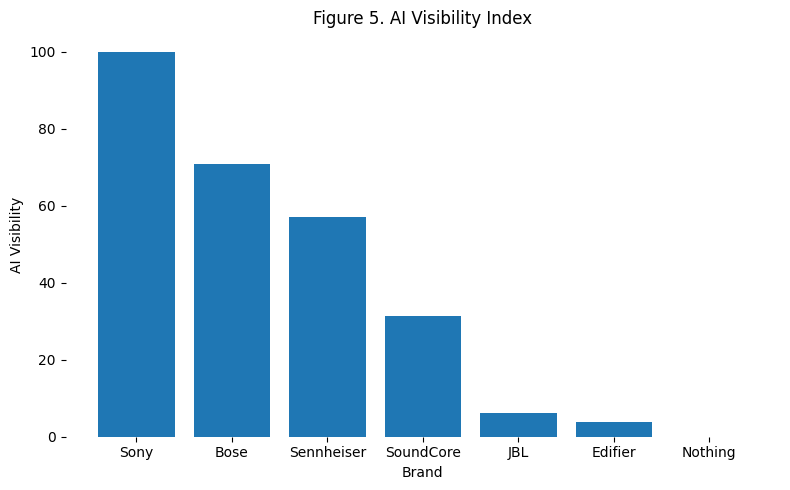

In [49]:
# ==========================================================
# Figure 5 AI Visibility
# ==========================================================

visibility = visibility.sort_values(
    "AI_Visibility",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    visibility["Brand"],
    visibility["AI_Visibility"]
)

plt.ylabel("AI Visibility")

plt.xlabel("Brand")

plt.title(
    "Figure 5. AI Visibility Index"
)

plt.box(False)

plt.tight_layout()

plt.savefig(

os.path.join(
FIGURE_DIR,
"Figure5_AIVisibility.png"
),

dpi=300

)

plt.show()

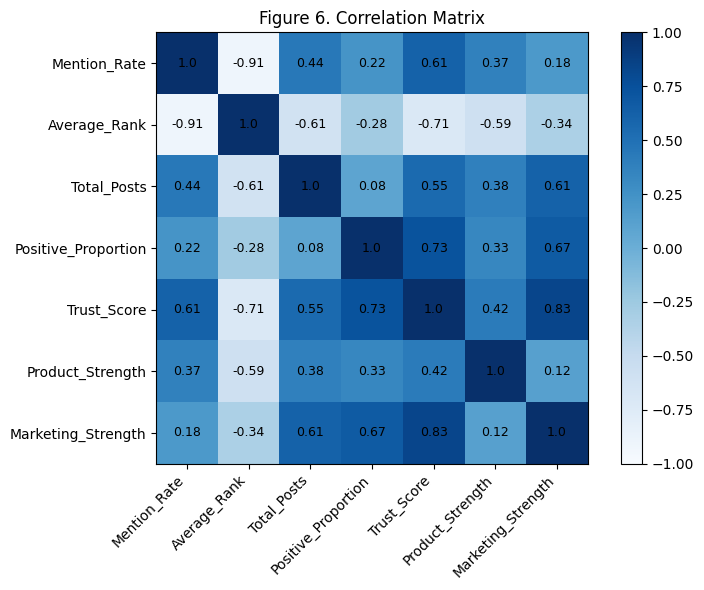

In [50]:
# ==========================================================
# Figure 6 Correlation Heatmap
# ==========================================================

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "Times New Roman"

corr_plot = corr.round(2)

fig, ax = plt.subplots(
    figsize=(8,6)
)

im = ax.imshow(
    corr_plot,
    cmap="Blues",
    vmin=-1,
    vmax=1
)

ax.set_xticks(
    np.arange(len(corr_plot.columns))
)

ax.set_xticklabels(
    corr_plot.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(
    np.arange(len(corr_plot.index))
)

ax.set_yticklabels(
    corr_plot.index
)

for i in range(len(corr_plot.index)):
    for j in range(len(corr_plot.columns)):
        ax.text(
            j,
            i,
            corr_plot.iloc[i,j],
            ha="center",
            va="center",
            fontsize=9
        )

plt.colorbar(im)

plt.title(
    "Figure 6. Correlation Matrix"
)

plt.tight_layout()

plt.savefig(

os.path.join(
FIGURE_DIR,
"Figure6_CorrelationHeatmap.png"
),

dpi=300

)

plt.show()